# 01. Exploratory Data Analysis (EDA)
## Agricultural Plant Disease Diagnosis System — Rice & Coffee


**Stage:** Raw data analysis
**Updated:** 2026-04-16

---

### Table of Contents

1. [Agricultural Dataset Challenges](#sec1)
2. [Dataset Overview](#sec2)
3. [Dataset Class Distribution](#sec3)
4. [Image Dimensions and Aspect Ratio](#sec4)
5. [Brightness and RGB Color Channels](#sec5)
6. [Disease Sample Visualization](#sec6)
7. [COCO Annotation Analysis](#sec7)
8. [Identifying Confusable Disease Pairs](#sec8)
9. [Macro F1 Evaluation Metric](#sec9)
10. [Summary and Preprocessing Recommendations](#sec10)

In [11]:
# ============================================================
# Environment Setup & Configuration
# ============================================================
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Bootstrap: locate project root and register notebook helpers ─
_cwd = Path(os.getcwd())
PROJECT_ROOT = next(
    (p for p in [_cwd, _cwd.parent, _cwd.parent.parent]
     if (p / "pyproject.toml").is_file() and (p / "src").is_dir()),
    _cwd.parent,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# ── Project imports ───────────────────────────────────────────
from src.config import (
    RANDOM_SEED,
    RICE_CLASSES, COFFEE_CLASSES,
    RICE_FOLDER,  COFFEE_FOLDER,
    PALETTE_RICE, PALETTE_COFFEE,
)
from src.reproducibility import set_seed
from src.coco import load_coco, build_image_df, build_ann_df
from src.visualization import (
    setup_plot_style,
    sample_color_stats,
    show_sample_grid,
    compute_mean_histogram,
)
from src.paths import find_project_root  # verified alias

set_seed(RANDOM_SEED)
setup_plot_style()

# ── Data paths ────────────────────────────────────────────────
RAW_DATA_ROOT = Path(os.environ.get("DATASET_SOURCE_ROOT", PROJECT_ROOT / "data" / "raw" / "coffee_rice_dataset"))
RICE_DIR      = RAW_DATA_ROOT / "rice_leaf_disease"
COFFEE_DIR    = RAW_DATA_ROOT / "coffee_leaf_disease"

---
<a id="sec1"></a>
## 1. Agricultural Dataset Challenges

Before conducting quantitative analysis, it is important to recognize the specific challenges of field-collected plant-leaf images. These factors directly affect preprocessing strategy, model selection, and evaluation methodology.

### 1.1 Image Acquisition Variability

Images were collected by farmers using mobile phones under uncontrolled natural lighting. This creates substantial variation in:
- **Brightness and white balance:** Morning, afternoon, and overcast lighting produce very different histograms for the same disease.
- **Viewpoint and distance:** An image may contain a single leaf, overlapping leaves, or an entire branch.
- **Image background:** Soil, grass, and healthy leaves may occupy a substantial portion of the image and create visual noise.

### 1.2 Class Imbalance

In practice, some diseases are more common than others, while some classes have fewer samples because they are harder to collect. This imbalance can bias a model toward majority classes and severely reduce minority-class performance, which is why **Macro F1-score** is selected as the primary evaluation metric instead of Accuracy.

### 1.3 Early-Stage Disease Similarity

Many rice and coffee diseases have visually similar symptoms during their early stages:
- **Rice:** Brown Spot and LeafBlast may appear similar in shape and color before developing characteristic symptoms.
- **Coffee:** Rust and AlgalLeafSpot can both create yellow-brown marks on the leaf surface.

### 1.4 Domain Shift Between Data Domains

The dataset contains two distinct domains: rice and coffee. The biological background, leaf morphology, and natural color characteristics of these crops create very different **image feature distributions**. When training a unified model, this domain shift requires particular attention so that optimization does not favor one domain while neglecting the other.

### 1.5 Small Positive Annotation Regions

Under the COCO annotation structure, each disease is marked by polygon segmentation regions. Many disease regions occupy only a small fraction of the full image, meaning that most image pixels belong to healthy leaf background. This is an important challenge for both classification and object-detection models.

In [12]:
# ============================================================
# Load COCO Annotations & Build Analysis DataFrames
# ============================================================
rice_coco   = load_coco(RICE_DIR   / "annotations.coco.json")
coffee_coco = load_coco(COFFEE_DIR / "annotations.coco.json")

rice_df   = build_image_df(rice_coco,   lambda fn: fn.split("/")[0])
coffee_df = build_image_df(coffee_coco, lambda fn: COFFEE_CLASSES[int(fn.split("/")[0])])

# Category-id → display-name maps for annotation-level analysis
RICE_CAT_MAP = {c["id"]: c["name"] for c in rice_coco["categories"]}
COFFEE_CAT_MAP = {
    c["id"]: COFFEE_CLASSES[int(c["name"])]
    for c in coffee_coco["categories"]
    if c["name"].isdigit()
}

rice_ann_df   = build_ann_df(rice_coco,   RICE_CAT_MAP)
coffee_ann_df = build_ann_df(coffee_coco, COFFEE_CAT_MAP)

print(f"Rice   : {len(rice_df):,} images | {len(rice_ann_df):,} annotations")
print(f"Coffee : {len(coffee_df):,} images | {len(coffee_ann_df):,} annotations")
print()
print("Rice class distribution:")
print(rice_df["label"].value_counts().rename("count").to_string())
print()
print("Coffee class distribution:")
print(coffee_df["label"].value_counts().rename("count").to_string())

Rice   : 3,421 images | 3,720 annotations
Coffee : 3,879 images | 3,842 annotations

Rice class distribution:
label
Healthy      1503
LeafBlast     793
Hispa         583
BrownSpot     542

Coffee class distribution:
label
Rust             1416
LeafMiner        1226
AlgalLeafSpot     969
PowderyMildew     268


---
<a id="sec2"></a>
## 2. Dataset Overview

The dataset is organized into two separate domains: **rice** and **coffee**. Both are stored in COCO (Common Objects in Context) format, including RGB images and JSON annotation files containing polygon segmentation information for each disease region.

The table below summarizes the basic statistics for each domain before detailed analysis.

In [13]:
# ============================================================
# Dataset Overview — Summary Statistics
# ============================================================
rice_counts   = rice_df["label"].value_counts()
coffee_counts = coffee_df["label"].value_counts()

print("=" * 68)
print(f"{'DATASET OVERVIEW':^68}")
print("=" * 68)

summary = pd.DataFrame({
    "Domain":             ["Rice", "Coffee", "Total"],
    "Class count":        [4,            4,                 8],
    "Image count":        [len(rice_df), len(coffee_df),    len(rice_df) + len(coffee_df)],
    "COCO annotation count": [len(rice_ann_df), len(coffee_ann_df),
                           len(rice_ann_df) + len(coffee_ann_df)],
    "Mean width (px)":    [f"{rice_df['width'].mean():.0f}",
                           f"{coffee_df['width'].mean():.0f}", "—"],
    "Mean height (px)":   [f"{rice_df['height'].mean():.0f}",
                           f"{coffee_df['height'].mean():.0f}", "—"],
})
print(summary.to_string(index=False))
print()

for domain, df, counts in [
    ("Rice", rice_df, rice_counts),
    ("Coffee", coffee_df, coffee_counts),
]:
    print(f"Detailed statistics — {domain}:")
    stats = df.groupby("label").agg(
        count   =("image_id",     "count"),
        w_mean  =("width",        "mean"),
        h_mean  =("height",       "mean"),
        ar_mean =("aspect_ratio", "mean"),
    ).round(1)
    stats["pct (%)"] = (stats["count"] / stats["count"].sum() * 100).round(1)
    stats = stats.reindex(RICE_CLASSES if domain == "Rice" else COFFEE_CLASSES)
    print(stats.to_string())
    ir = counts.max() / counts.min()
    cv = counts.std() / counts.mean() * 100
    print(f"  Imbalance Ratio (IR) = {ir:.2f}x  |  CV = {cv:.1f}%")
    print()

                          DATASET OVERVIEW                          
Domain  Class count  Image count  COCO annotation count Mean width (px) Mean height (px)
  Rice            4         3421                   3720            2031             2026
Coffee            4         3879                   3842             971             1154
 Total            8         7300                   7562               —                —

Detailed statistics — Rice:
           count  w_mean  h_mean  ar_mean  pct (%)
label                                             
BrownSpot    542  2136.1  2133.3      1.0     15.8
Healthy     1503  2101.3  2097.6      1.0     43.9
Hispa        583  2080.3  2066.7      1.0     17.0
LeafBlast    793  1791.4  1788.3      1.0     23.2
  Imbalance Ratio (IR) = 2.77x  |  CV = 52.1%

Detailed statistics — Coffee:
               count  w_mean  h_mean  ar_mean  pct (%)
label                                                 
LeafMiner       1226   986.9  1149.4      0.9     31.

---
<a id="sec3"></a>
## 3. Dataset Class Distribution

Class-distribution analysis is the first step in assessing dataset balance. Two metrics are commonly used to quantify imbalance:

- **Imbalance Ratio (IR):** Ratio between the majority-class and minority-class sample counts:

$$\text{IR} = \frac{N_{\text{majority}}}{N_{\text{minority}}}$$

A value of $\text{IR} > 3$ is commonly considered substantial imbalance that may require intervention.

- **Coefficient of Variation (CV):** Measures the dispersion of sample counts across classes:

$$\text{CV} = \frac{\sigma_N}{\mu_N} \times 100\%$$

where $\sigma_N$ and $\mu_N$ are the standard deviation and mean of class sample counts, respectively. A high CV indicates an uneven distribution.

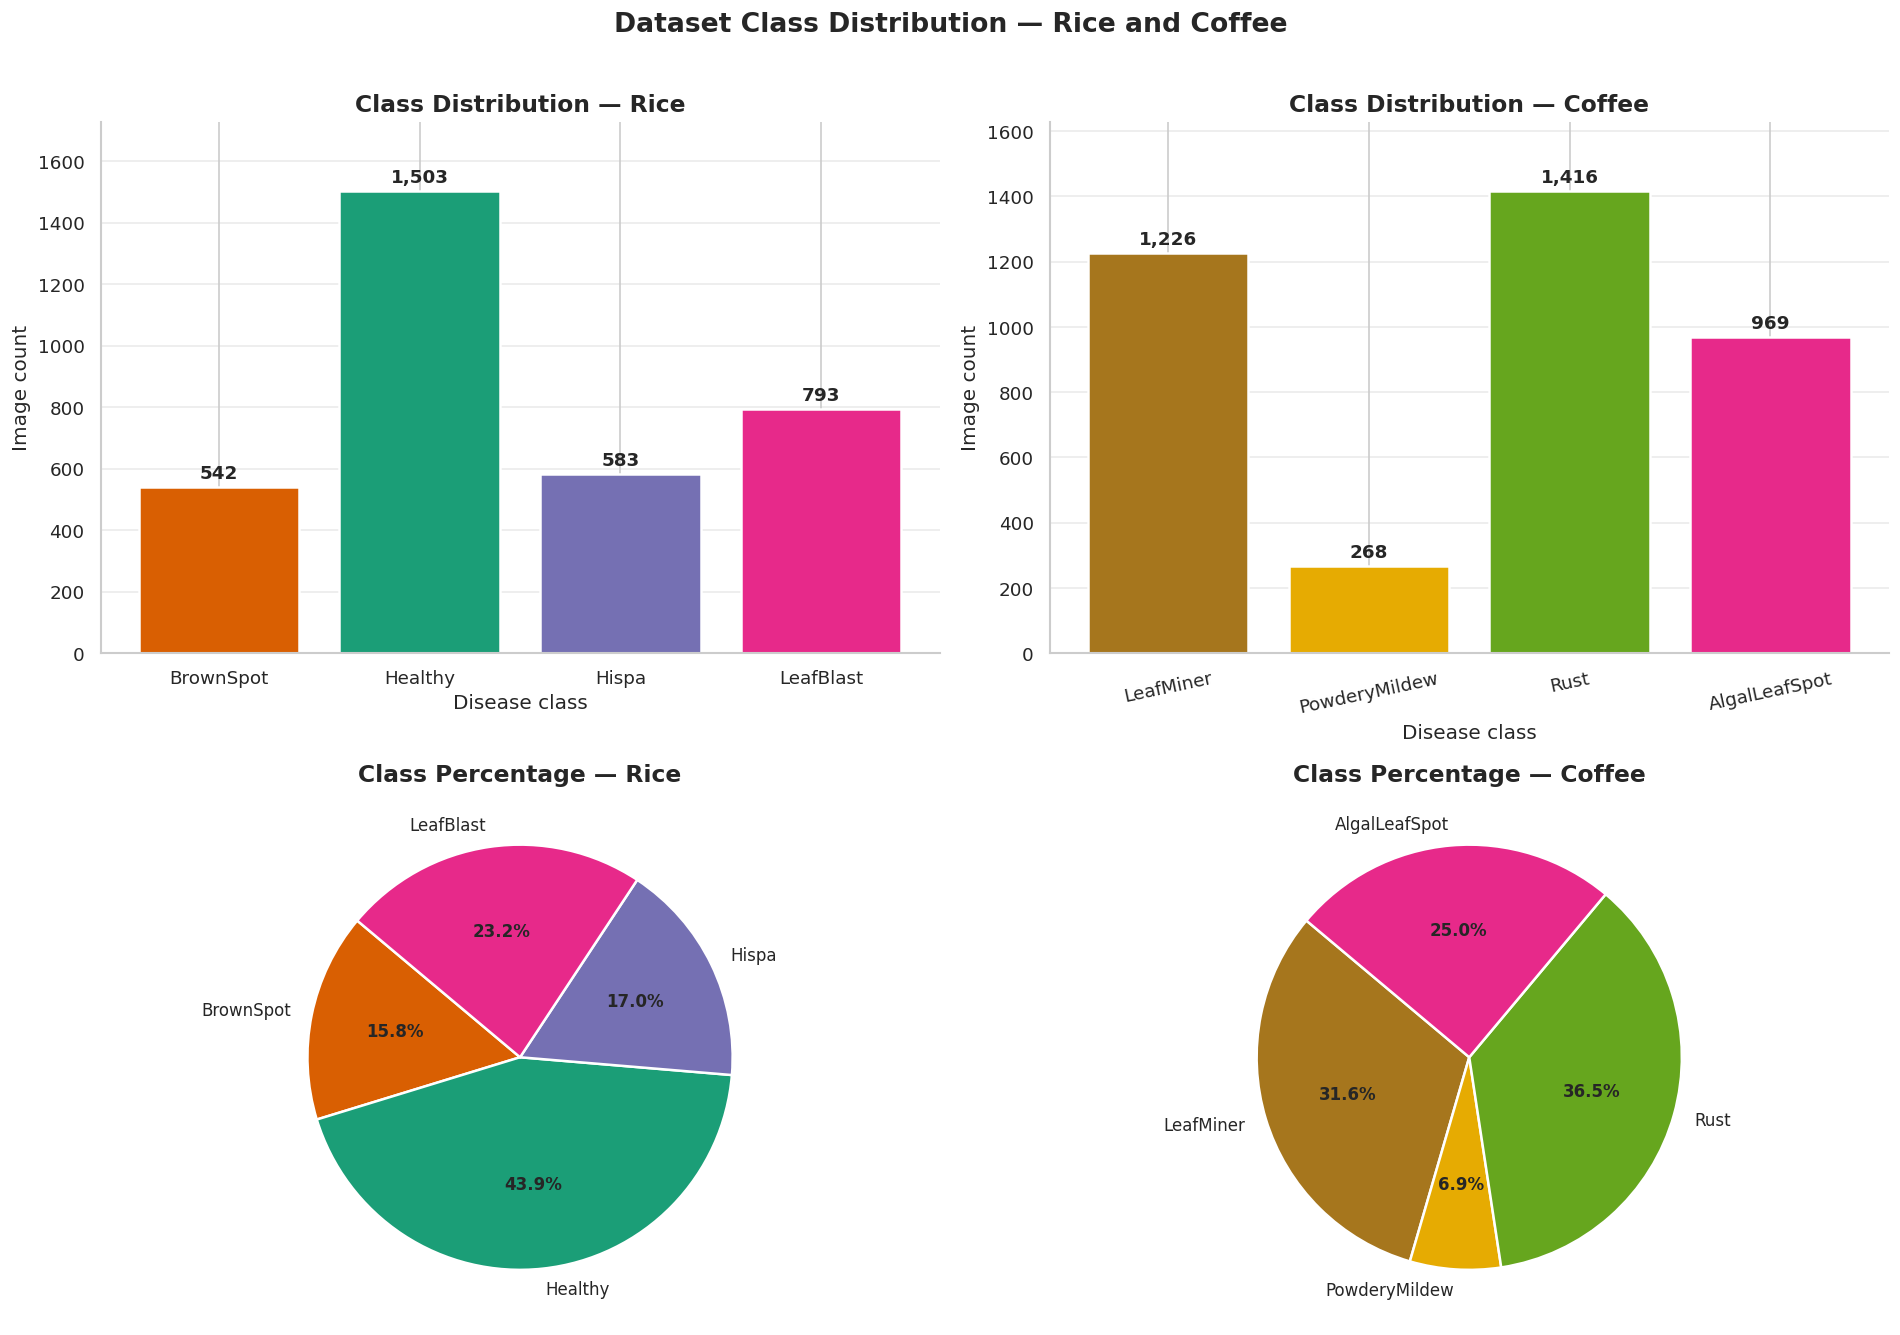

Rice: IR = 2.77x | CV = 52.1% | majority=Healthy (1,503) | minority=BrownSpot (542)
Coffee: IR = 5.28x | CV = 51.8% | majority=Rust (1,416) | minority=PowderyMildew (268)


In [14]:
# ============================================================
# Class Distribution — Bar Charts & Pie Charts
# ============================================================
rice_counts   = rice_df["label"].value_counts().reindex(RICE_CLASSES)
coffee_counts = coffee_df["label"].value_counts().reindex(COFFEE_CLASSES)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Dataset Class Distribution — Rice and Coffee",
             fontsize=16, fontweight="bold", y=1.01)

# ── Rice bar ─────────────────────────────────────────────────
bars = axes[0, 0].bar(rice_counts.index, rice_counts.values,
                      color=PALETTE_RICE, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, rice_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width() / 2, val + 15,
                    f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0, 0].set_title("Class Distribution — Rice")
axes[0, 0].set_xlabel("Disease class")
axes[0, 0].set_ylabel("Image count")
axes[0, 0].set_ylim(0, rice_counts.max() * 1.15)
axes[0, 0].yaxis.grid(True, alpha=0.4, zorder=0)

# ── Coffee bar ───────────────────────────────────────────────
bars = axes[0, 1].bar(coffee_counts.index, coffee_counts.values,
                      color=PALETTE_COFFEE, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, coffee_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width() / 2, val + 15,
                    f"{val:,}", ha="center", va="bottom", fontweight="bold", fontsize=11)
axes[0, 1].set_title("Class Distribution — Coffee")
axes[0, 1].set_xlabel("Disease class")
axes[0, 1].set_ylabel("Image count")
axes[0, 1].tick_params(axis="x", rotation=12)
axes[0, 1].set_ylim(0, coffee_counts.max() * 1.15)
axes[0, 1].yaxis.grid(True, alpha=0.4, zorder=0)

# ── Rice pie ─────────────────────────────────────────────────
_, _, autotexts = axes[1, 0].pie(
    rice_counts.values, labels=rice_counts.index,
    colors=PALETTE_RICE, autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1, 0].set_title("Class Percentage — Rice")

# ── Coffee pie ───────────────────────────────────────────────
_, _, autotexts = axes[1, 1].pie(
    coffee_counts.values, labels=coffee_counts.index,
    colors=PALETTE_COFFEE, autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}, textprops={"fontsize": 10},
)
for at in autotexts:
    at.set_fontweight("bold")
axes[1, 1].set_title("Class Percentage — Coffee")

plt.tight_layout()
plt.show()

for domain, counts in [("Rice", rice_counts), ("Coffee", coffee_counts)]:
    ir = counts.max() / counts.min()
    cv = counts.std() / counts.mean() * 100
    print(f"{domain}: IR = {ir:.2f}x | CV = {cv:.1f}% "
          f"| majority={counts.idxmax()} ({counts.max():,}) "
          f"| minority={counts.idxmin()} ({counts.min():,})")

---
<a id="sec4"></a>
## 4. Image Dimensions and Aspect Ratio

Variation in image dimensions is a direct training challenge because deep-learning models require fixed-size inputs. Inappropriate resizing can cause:

- **Loss of disease detail:** When a very large image (for example, 3000×3000 px) is resized to 224×224 px, small disease regions may become too small to distinguish.
- **Aspect-ratio distortion:** Resizing to a square without padding can stretch leaf morphology and affect shape features.

**Aspect Ratio** is defined as $AR = W/H$. A value of $AR = 1$ indicates a square image, $AR > 1$ a landscape image, and $AR < 1$ a portrait image.

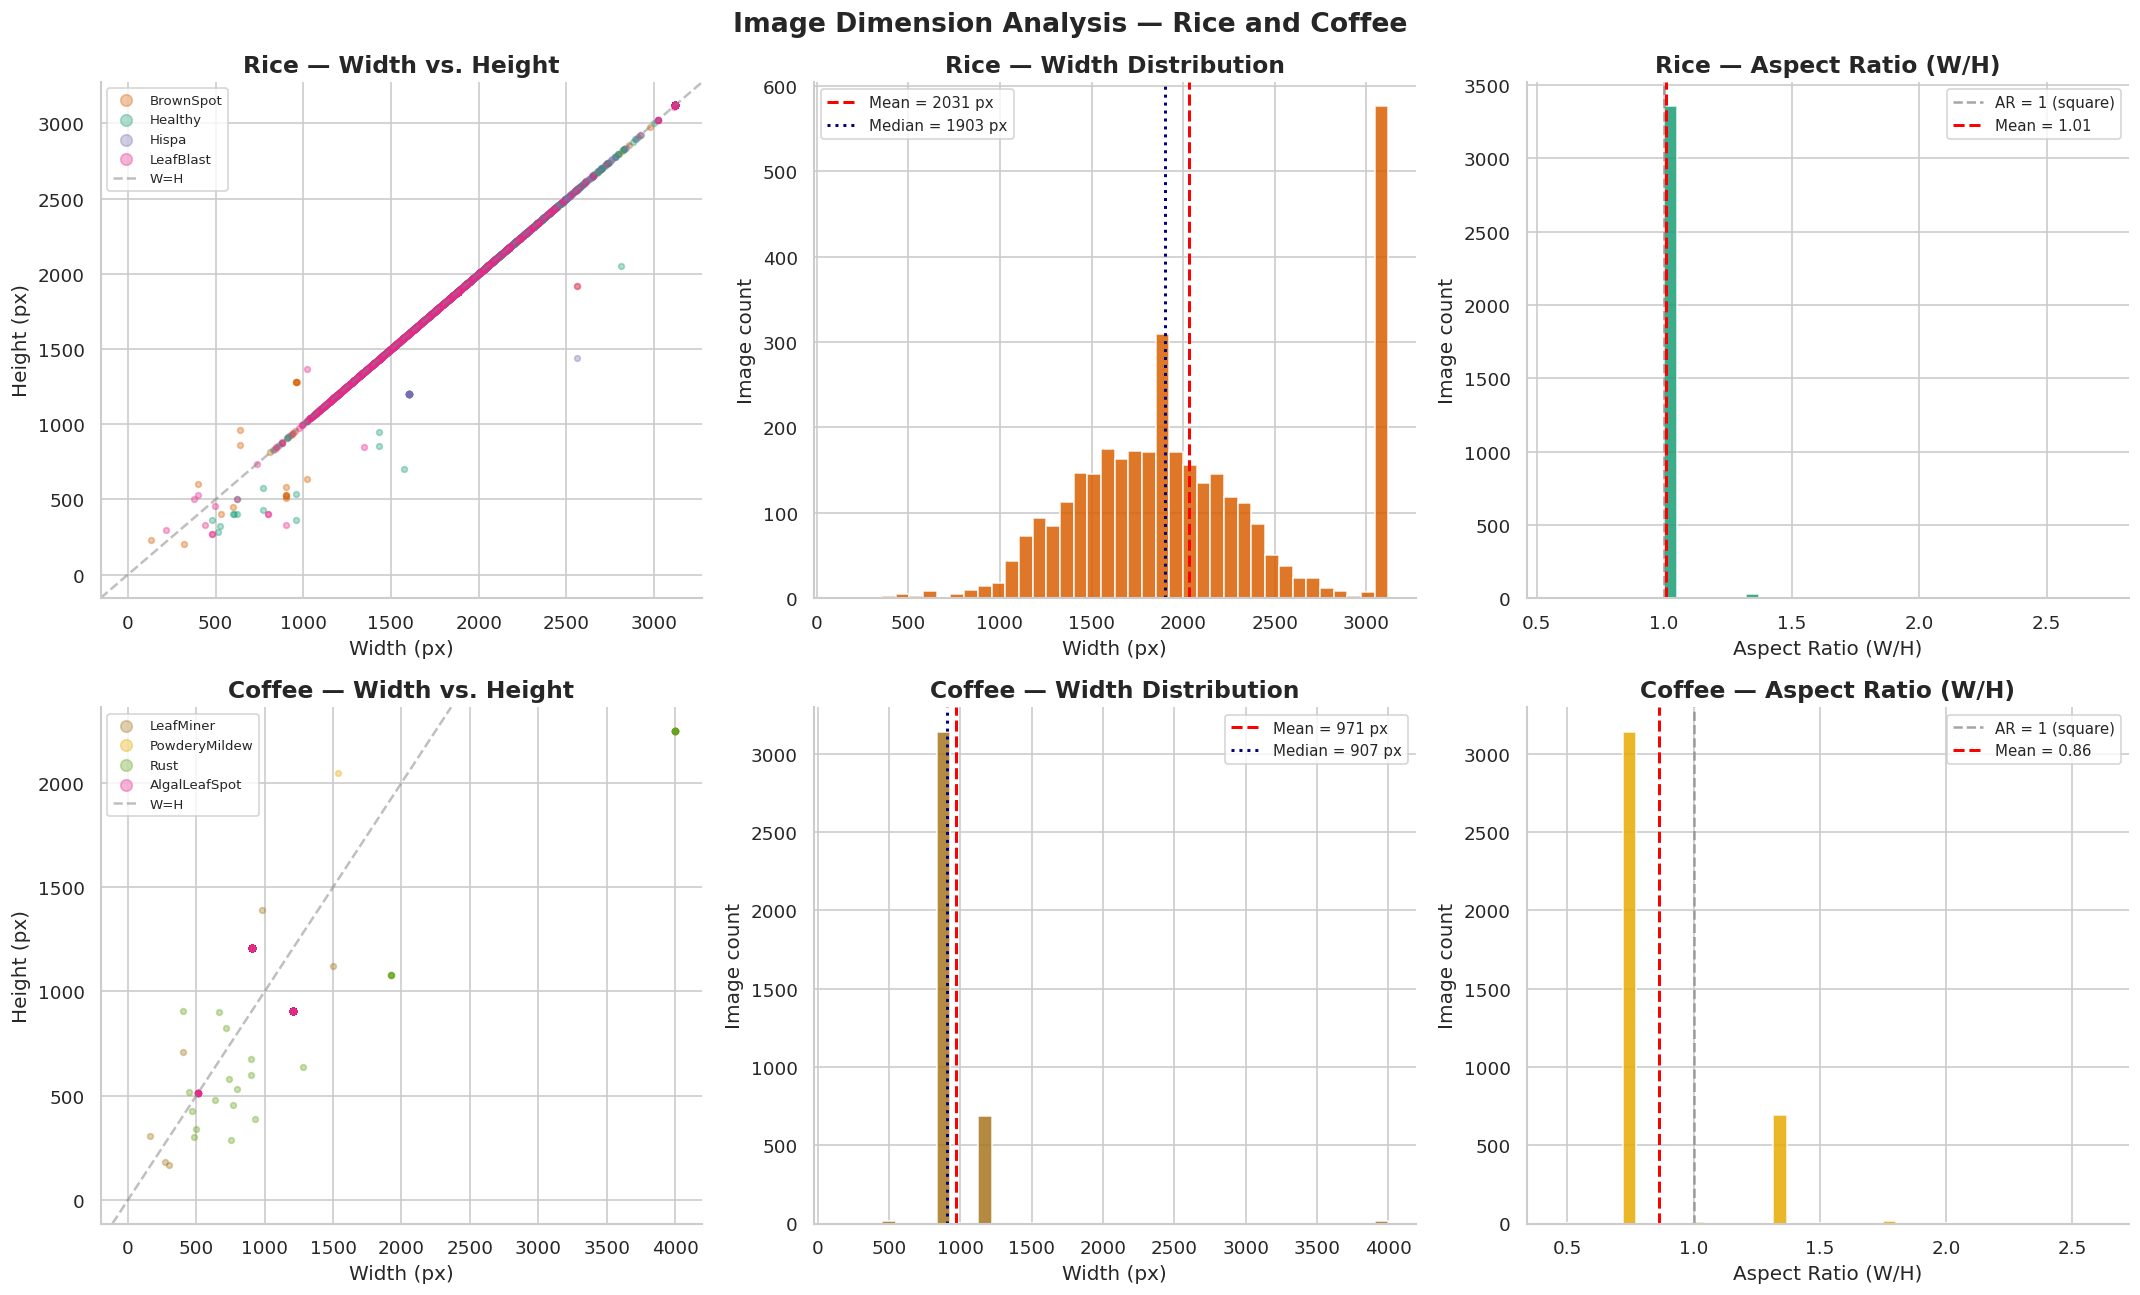

Rice: width=[132, 3120] px | height=[206, 3120] px | AR=[0.57, 2.71]
Coffee: width=[163, 4000] px | height=[168, 2250] px | AR=[0.45, 2.61]


In [15]:
# ============================================================
# Image Dimension Analysis
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Image Dimension Analysis — Rice and Coffee",
             fontsize=16, fontweight="bold")

datasets = [
    ("Rice",    rice_df,   RICE_CLASSES,   PALETTE_RICE,   axes[0]),
    ("Coffee", coffee_df, COFFEE_CLASSES, PALETTE_COFFEE, axes[1]),
]

for domain, df, classes, palette, axrow in datasets:
    for cls, color in zip(classes, palette):
        mask = df["label"] == cls
        axrow[0].scatter(df[mask]["width"], df[mask]["height"],
                         c=color, alpha=0.35, s=12, label=cls)
    axrow[0].axline((0, 0), slope=1, color="gray", ls="--", alpha=0.5, label="W=H")
    axrow[0].set_title(f"{domain} — Width vs. Height")
    axrow[0].set_xlabel("Width (px)")
    axrow[0].set_ylabel("Height (px)")
    axrow[0].legend(fontsize=8, markerscale=2)

    axrow[1].hist(df["width"], bins=40, color=palette[0], edgecolor="white", alpha=0.85)
    axrow[1].axvline(df["width"].mean(), color="red", ls="--", lw=1.8,
                     label=f"Mean = {df['width'].mean():.0f} px")
    axrow[1].axvline(df["width"].median(), color="navy", ls=":", lw=1.8,
                     label=f"Median = {df['width'].median():.0f} px")
    axrow[1].set_title(f"{domain} — Width Distribution")
    axrow[1].set_xlabel("Width (px)")
    axrow[1].set_ylabel("Image count")
    axrow[1].legend(fontsize=9)

    axrow[2].hist(df["aspect_ratio"], bins=40, color=palette[1], edgecolor="white", alpha=0.85)
    axrow[2].axvline(1.0, color="gray", ls="--", lw=1.5, alpha=0.7, label="AR = 1 (square)")
    axrow[2].axvline(df["aspect_ratio"].mean(), color="red", ls="--", lw=1.8,
                     label=f"Mean = {df['aspect_ratio'].mean():.2f}")
    axrow[2].set_title(f"{domain} — Aspect Ratio (W/H)")
    axrow[2].set_xlabel("Aspect Ratio (W/H)")
    axrow[2].set_ylabel("Image count")
    axrow[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

for domain, df in [("Rice", rice_df), ("Coffee", coffee_df)]:
    print(f"{domain}: width=[{df['width'].min()}, {df['width'].max()}] px | "
          f"height=[{df['height'].min()}, {df['height'].max()}] px | "
          f"AR=[{df['aspect_ratio'].min():.2f}, {df['aspect_ratio'].max():.2f}]")

---
<a id="sec5"></a>
## 5. Brightness and RGB Color Channels

### 5.1 Perceptual Luminance

The perceptual brightness of an RGB pixel is not a simple average of the three color channels. It is computed using the ITU-R BT.601 standard, which reflects human visual sensitivity:

$$L(i, j) = 0.299 \cdot R(i, j) + 0.587 \cdot G(i, j) + 0.114 \cdot B(i, j)$$

The mean luminance of an image $I$ with dimensions $H \times W$ is computed as:

$$\mu_L(I) = \frac{1}{H \cdot W} \sum_{i=1}^{H} \sum_{j=1}^{W} L(i, j)$$

### 5.2 Local Contrast

Contrast is estimated using the standard deviation of the luminance channel:

$$\sigma_L(I) = \sqrt{\frac{1}{H \cdot W} \sum_{i=1}^{H} \sum_{j=1}^{W} \left(L(i,j) - \mu_L\right)^2}$$

A low $\sigma_L$ indicates uniform brightness, while a high $\sigma_L$ indicates greater tonal variation, which is more common in field images.

### 5.3 Preprocessing Implications

Differences in brightness and color distributions across disease classes suggest that:
- **Per-channel normalization** should be based on training-set statistics rather than ImageNet statistics.
- **Brightness-related augmentation** (ColorJitter, RandomBrightnessContrast) is needed to improve model robustness to field-lighting variation.

In [16]:
# ============================================================
# Sample Brightness & Color Channel Statistics
# Uses visualize.sample_color_stats() — samples 50 images/class
# ============================================================
N_SAMPLE = 50

print("Sampling rice images for color analysis...")
rice_color = sample_color_stats(RICE_DIR, RICE_CLASSES, RICE_FOLDER, n=N_SAMPLE)
print("Sampling coffee images for color analysis...")
coffee_color = sample_color_stats(COFFEE_DIR, COFFEE_CLASSES, COFFEE_FOLDER, n=N_SAMPLE)
print(f"Done. Rice: {len(rice_color)} | Coffee: {len(coffee_color)} samples")

print()
print("Brightness statistics by class (Rice):")
print(rice_color.groupby("class")[["brightness", "contrast"]].agg(["mean", "std"]).round(2).to_string())
print()
print("Brightness statistics by class (Coffee):")
print(coffee_color.groupby("class")[["brightness", "contrast"]].agg(["mean", "std"]).round(2).to_string())

Sampling rice images for color analysis...
Sampling coffee images for color analysis...
Done. Rice: 200 | Coffee: 200 samples

Brightness statistics by class (Rice):
          brightness        contrast       
                mean    std     mean    std
class                                      
BrownSpot     197.63  16.06    45.49   8.96
Healthy       199.92  10.44    46.28   9.15
Hispa         200.28  16.50    45.63  10.23
LeafBlast     195.33  19.71    42.30  13.41

Brightness statistics by class (Coffee):
              brightness        contrast      
                    mean    std     mean   std
class                                         
AlgalLeafSpot     116.06  10.65    57.05  4.41
LeafMiner         127.47  12.28    51.91  5.34
PowderyMildew     116.29   7.70    55.50  5.71
Rust              127.58  11.05    51.62  5.83


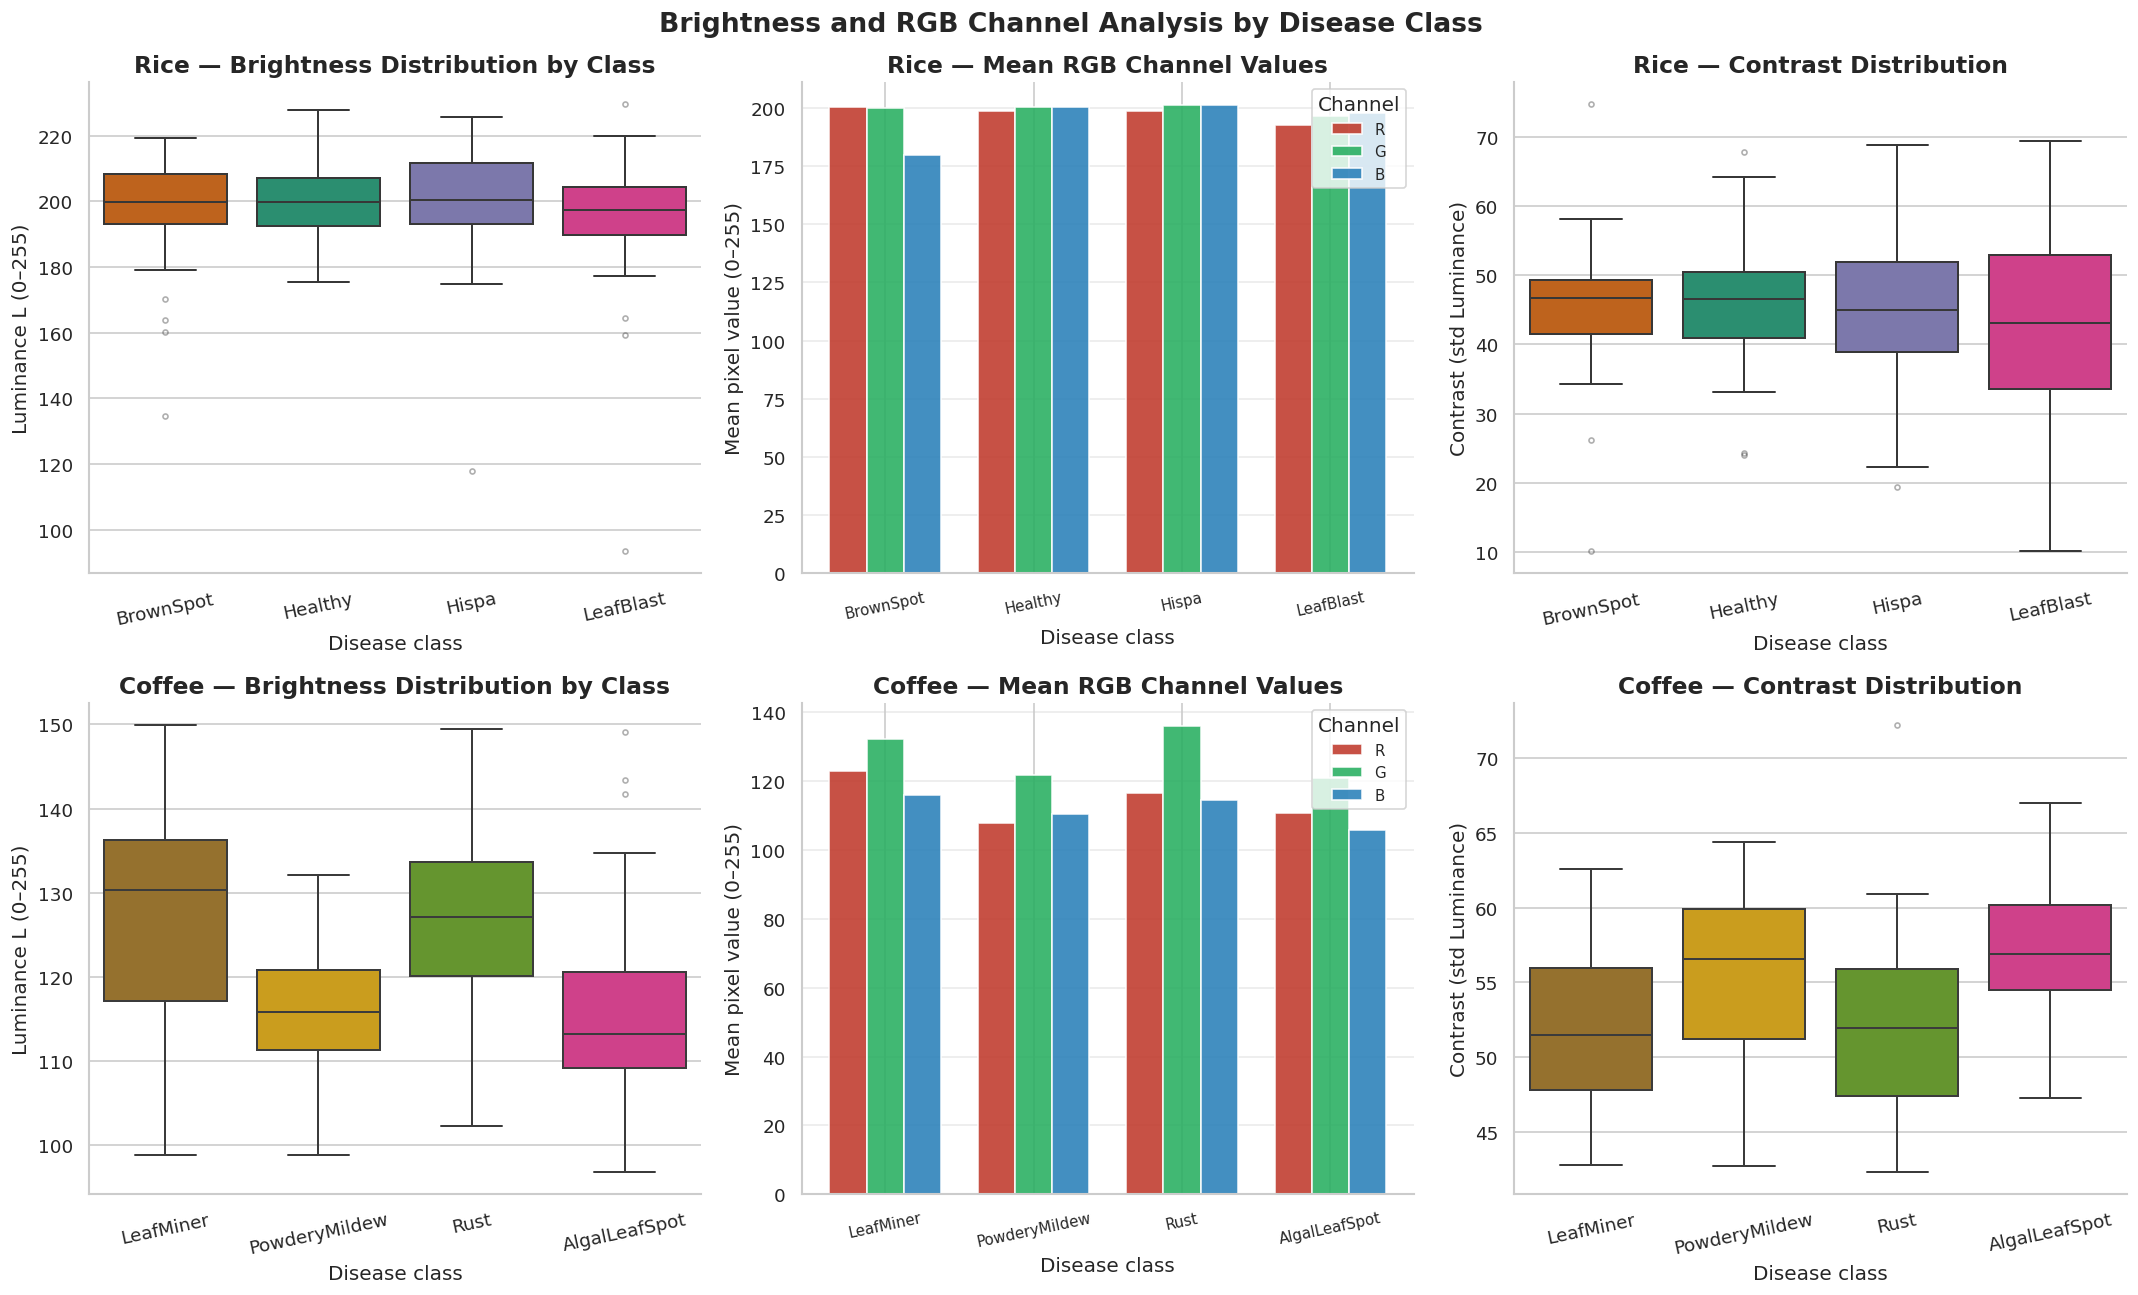

In [17]:
# ============================================================
# Brightness & RGB Channel Visualizations
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Brightness and RGB Channel Analysis by Disease Class",
             fontsize=16, fontweight="bold")

datasets = [
    ("Rice",    rice_color,   RICE_CLASSES,   PALETTE_RICE,   axes[0]),
    ("Coffee", coffee_color, COFFEE_CLASSES, PALETTE_COFFEE, axes[1]),
]

for domain, color_df, classes, palette, axrow in datasets:
    sns.boxplot(data=color_df, x="class", y="brightness", order=classes,
                palette=palette, ax=axrow[0], linewidth=1.2,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
    axrow[0].set_title(f"{domain} — Brightness Distribution by Class")
    axrow[0].set_xlabel("Disease class")
    axrow[0].set_ylabel("Luminance L (0–255)")
    axrow[0].tick_params(axis="x", rotation=12)

    rgb_means = (color_df.groupby("class")[["r_mean", "g_mean", "b_mean"]]
                 .mean().reindex(classes))
    x, w = np.arange(len(classes)), 0.25
    axrow[1].bar(x - w, rgb_means["r_mean"], width=w, color="#C0392B", label="R", alpha=0.88, edgecolor="white")
    axrow[1].bar(x,     rgb_means["g_mean"], width=w, color="#27AE60", label="G", alpha=0.88, edgecolor="white")
    axrow[1].bar(x + w, rgb_means["b_mean"], width=w, color="#2980B9", label="B", alpha=0.88, edgecolor="white")
    axrow[1].set_xticks(x)
    axrow[1].set_xticklabels(classes, rotation=12, fontsize=9)
    axrow[1].set_title(f"{domain} — Mean RGB Channel Values")
    axrow[1].set_xlabel("Disease class")
    axrow[1].set_ylabel("Mean pixel value (0–255)")
    axrow[1].legend(title="Channel", fontsize=9)
    axrow[1].yaxis.grid(True, alpha=0.4)

    sns.boxplot(data=color_df, x="class", y="contrast", order=classes,
                palette=palette, ax=axrow[2], linewidth=1.2,
                flierprops={"marker": "o", "markersize": 3, "alpha": 0.4})
    axrow[2].set_title(f"{domain} — Contrast Distribution")
    axrow[2].set_xlabel("Disease class")
    axrow[2].set_ylabel("Contrast (std Luminance)")
    axrow[2].tick_params(axis="x", rotation=12)

plt.tight_layout()
plt.show()

---
<a id="sec6"></a>
## 6. Disease Sample Visualization

Directly inspecting image samples from each disease class helps identify characteristic visual patterns and cases that may challenge the model, such as blur, overlapping leaves, distant views, and early-stage disease. Each row below shows four randomly selected examples from each disease class.

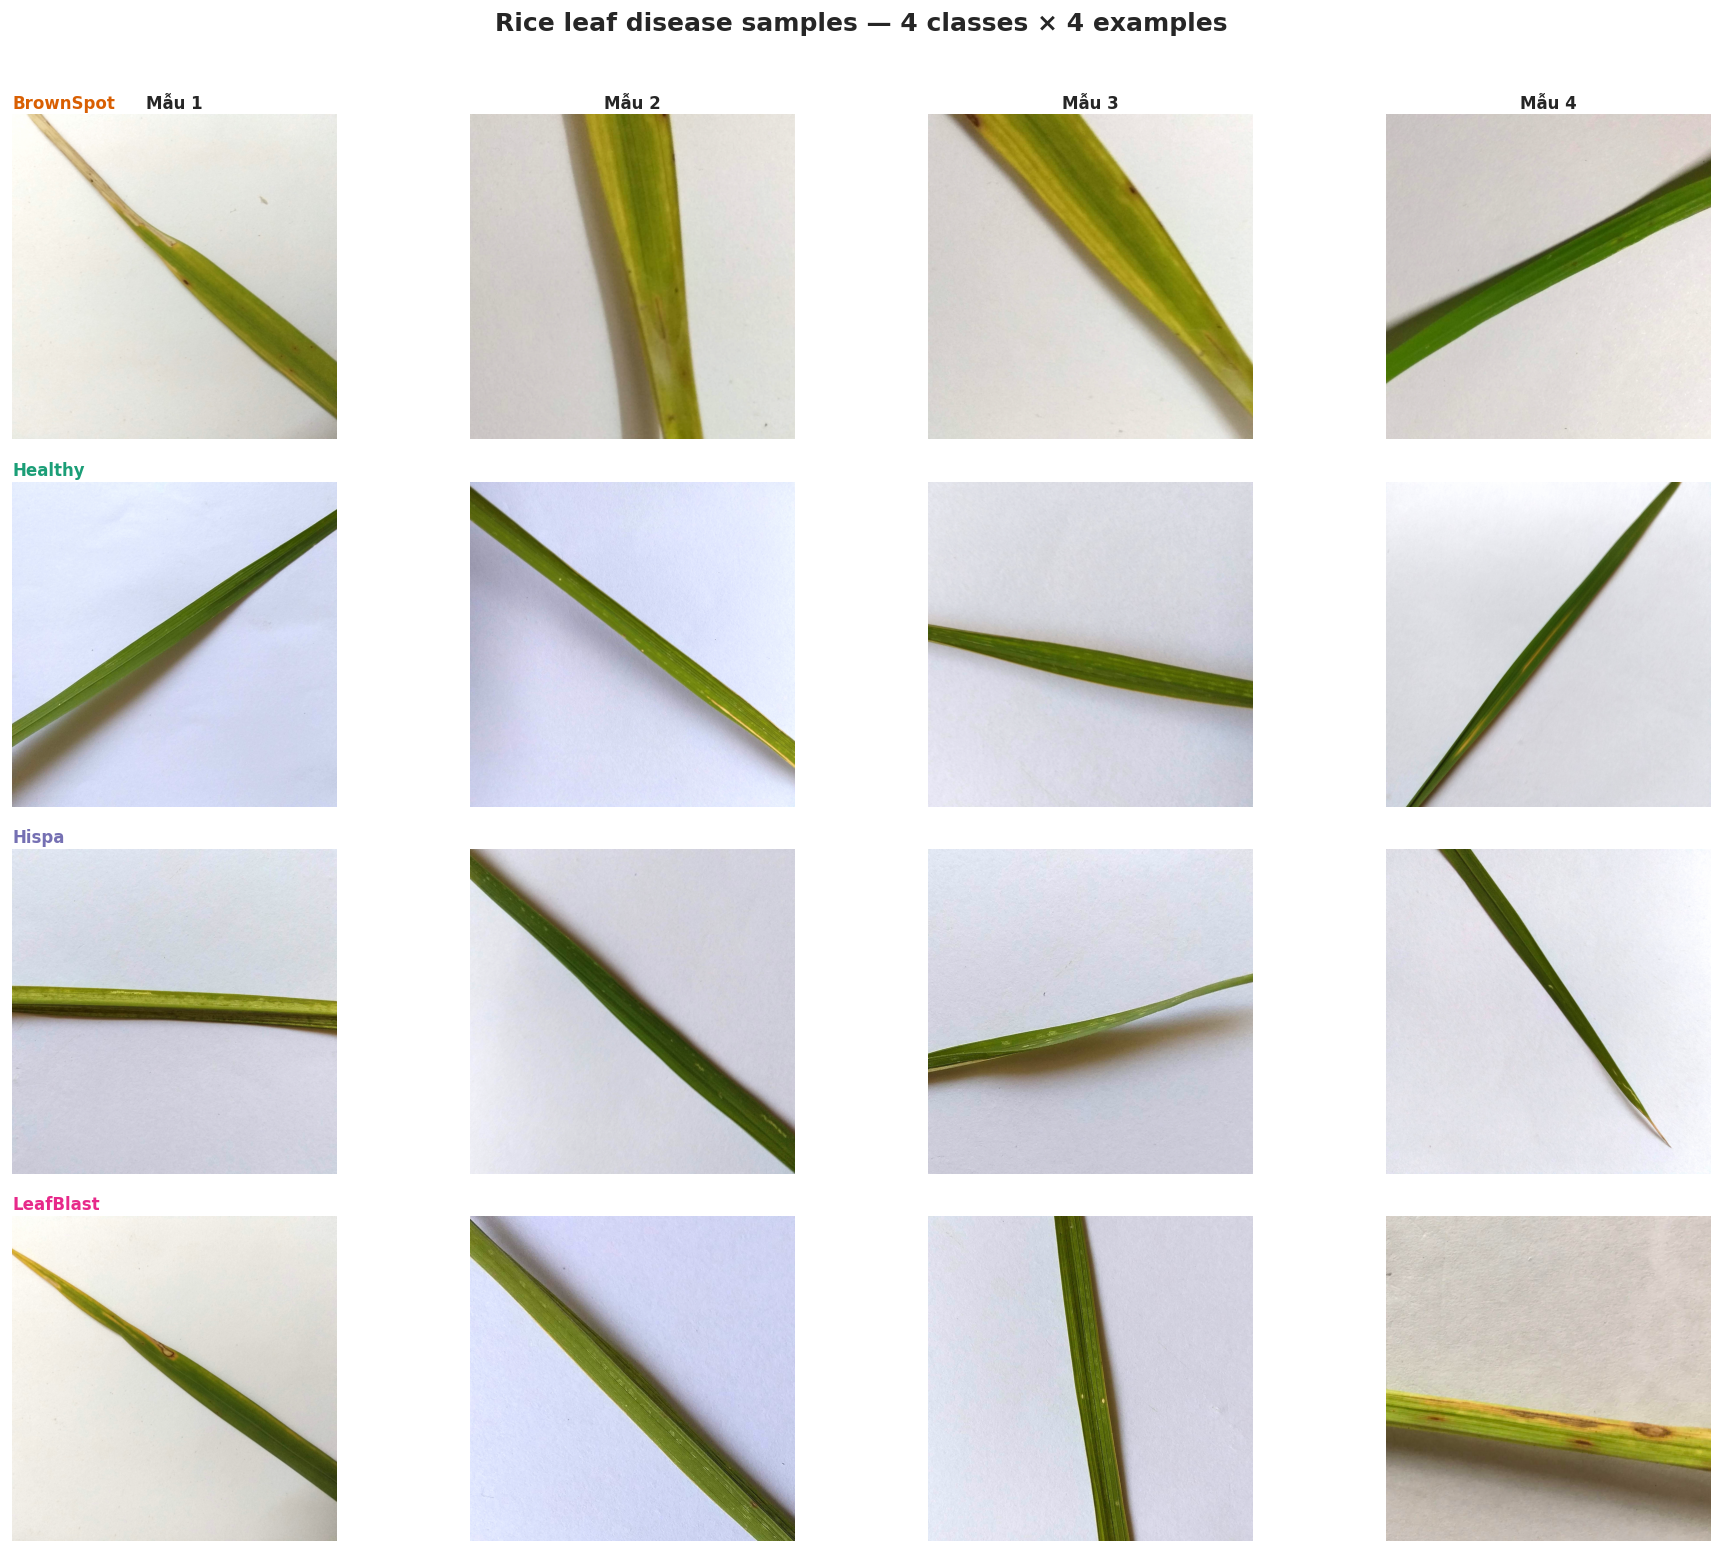

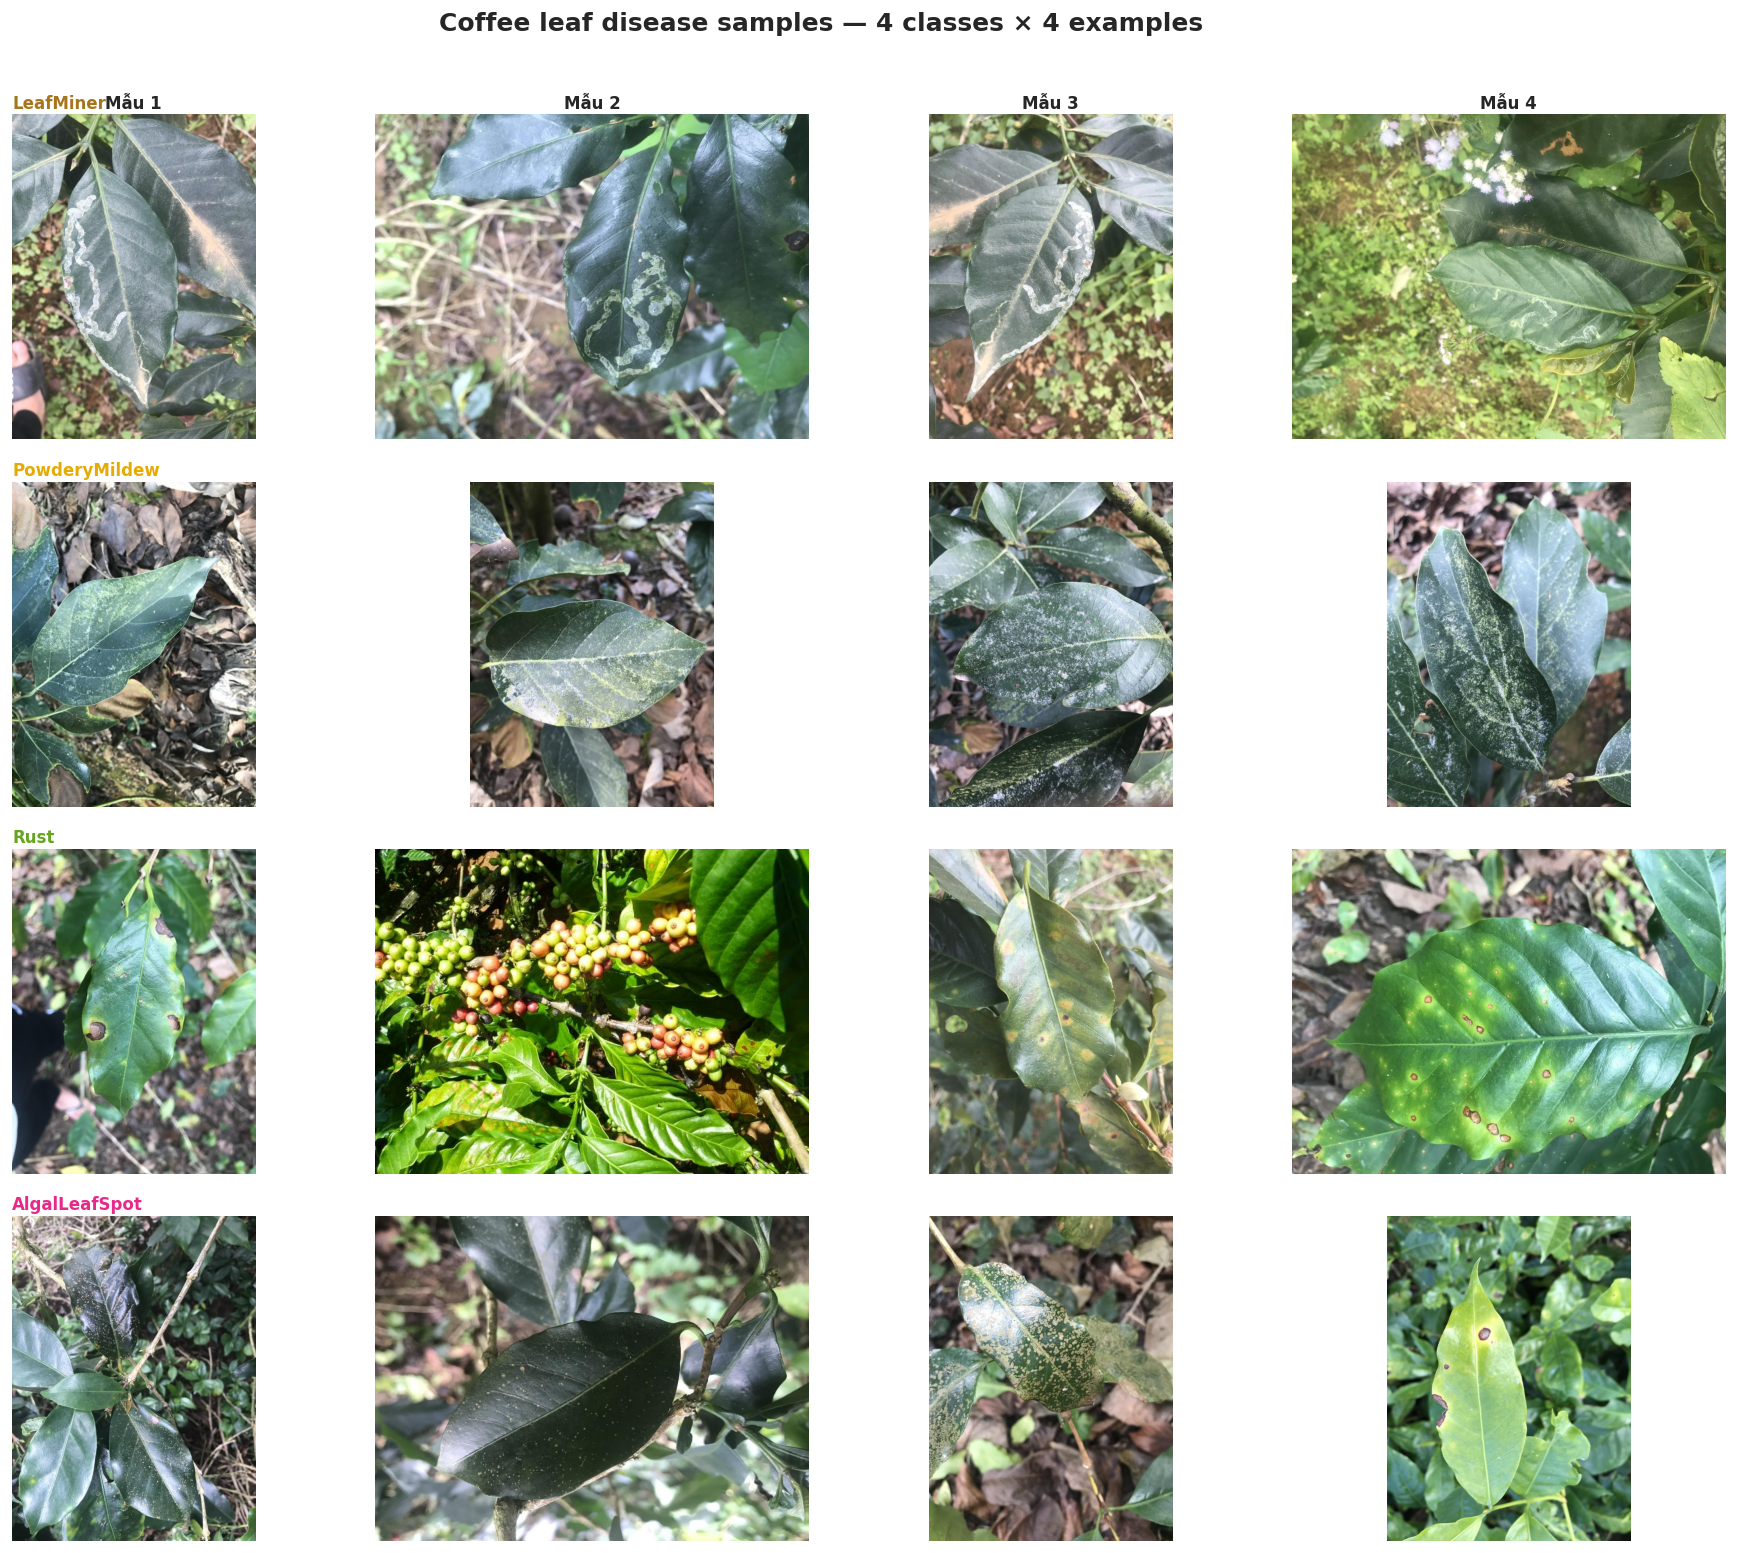

In [18]:
# ============================================================
# Sample Image Grid Visualization
# Uses visualize.show_sample_grid()
# ============================================================
show_sample_grid(RICE_DIR,   RICE_CLASSES,   RICE_FOLDER,   PALETTE_RICE,
                 "Rice leaf disease samples — 4 classes × 4 examples")
show_sample_grid(COFFEE_DIR, COFFEE_CLASSES, COFFEE_FOLDER, PALETTE_COFFEE,
                 "Coffee leaf disease samples — 4 classes × 4 examples")

---
<a id="sec7"></a>
## 7. COCO Annotation Analysis

The dataset is annotated in COCO format. This section uses annotation records and **bounding-box area**, not polygon mask area, for its size statistics.

- How many disease regions are marked per image on average?
- What fraction of each image is covered by annotation bounding boxes?
- Do bounding-box sizes differ across classes?

These findings directly inform decisions about:
1. Using a bounding-box crop or the full image as model input.
2. Designing an augmentation strategy appropriate for disease-region scale.

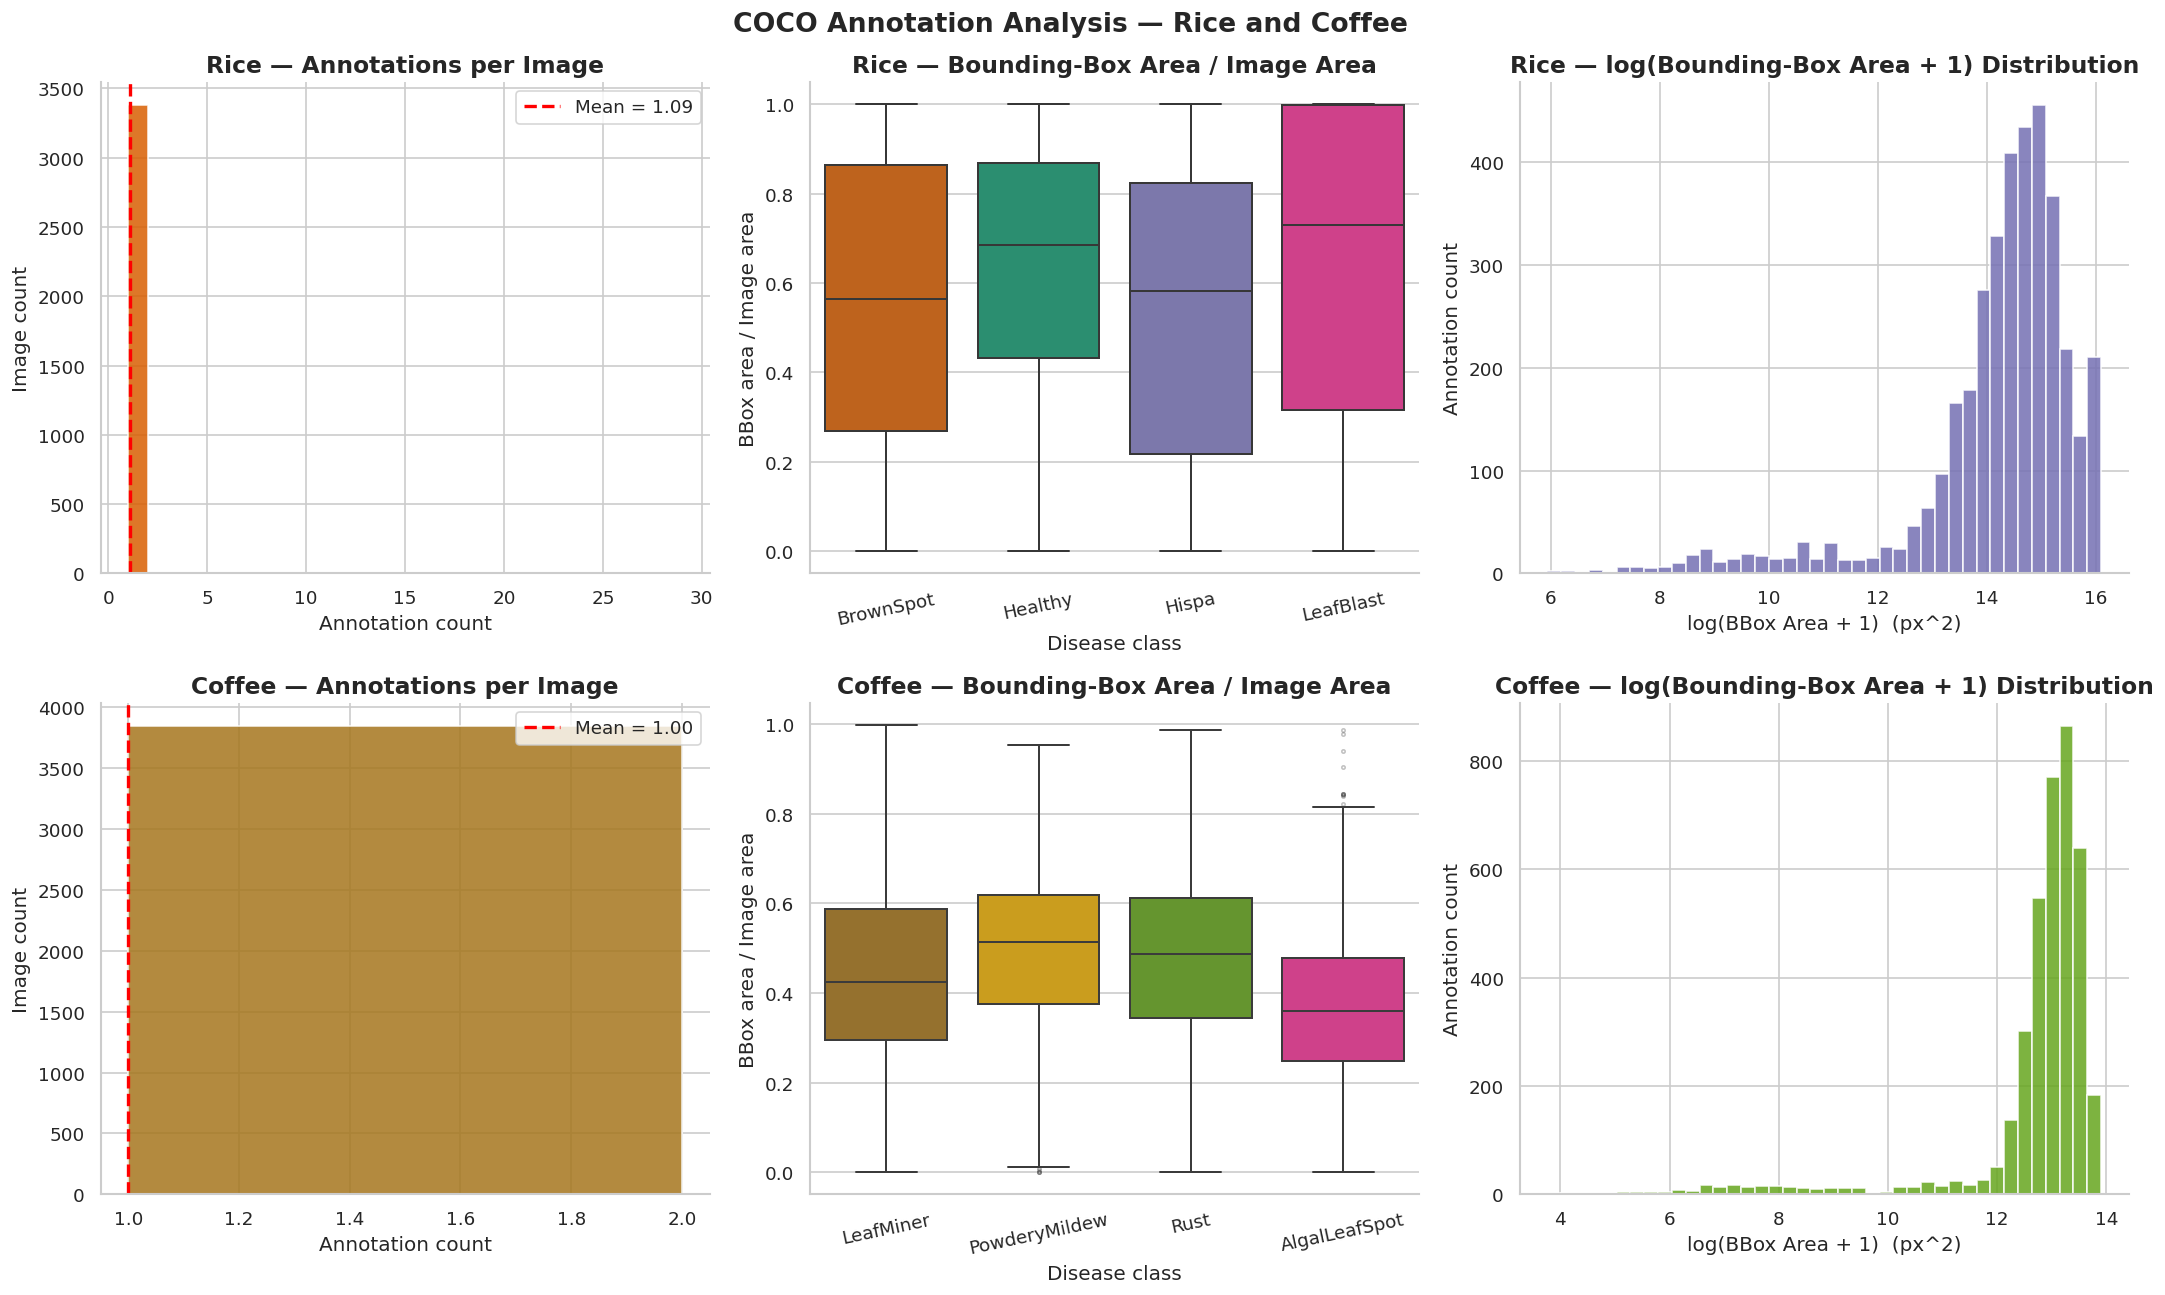

Rice: ann/img — min=1, max=28, mean=1.09
Coffee: ann/img — min=1, max=1, mean=1.00


In [19]:
# ============================================================
# COCO Annotation Analysis
# ============================================================
rice_ann_full   = rice_ann_df.merge(
    rice_df[["image_id", "width", "height"]], on="image_id", how="left")
coffee_ann_full = coffee_ann_df.merge(
    coffee_df[["image_id", "width", "height"]], on="image_id", how="left")

rice_ann_full["rel_area"]   = (rice_ann_full["bbox_area"]
                                / (rice_ann_full["width"] * rice_ann_full["height"])).clip(upper=1)
coffee_ann_full["rel_area"] = (coffee_ann_full["bbox_area"]
                                / (coffee_ann_full["width"] * coffee_ann_full["height"])).clip(upper=1)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("COCO Annotation Analysis — Rice and Coffee",
             fontsize=16, fontweight="bold")

datasets = [
    ("Rice",    rice_ann_df,   rice_ann_full,   RICE_CLASSES,   PALETTE_RICE,   axes[0]),
    ("Coffee", coffee_ann_df, coffee_ann_full, COFFEE_CLASSES, PALETTE_COFFEE, axes[1]),
]

for domain, ann_df, ann_full, classes, palette, axrow in datasets:
    apc = ann_df.groupby("image_id").size()
    axrow[0].hist(apc.values, bins=range(1, min(int(apc.max()) + 2, 30)),
                  color=palette[0], edgecolor="white", alpha=0.85)
    axrow[0].axvline(apc.mean(), color="red", ls="--", lw=2, label=f"Mean = {apc.mean():.2f}")
    axrow[0].set_title(f"{domain} — Annotations per Image")
    axrow[0].set_xlabel("Annotation count")
    axrow[0].set_ylabel("Image count")
    axrow[0].legend()

    valid = ann_full[ann_full["class_name"].isin(classes)]
    order = [c for c in classes if c in valid["class_name"].values]
    pal   = [p for c, p in zip(classes, palette) if c in order]
    sns.boxplot(data=valid, x="class_name", y="rel_area", order=order,
                palette=pal, ax=axrow[1], linewidth=1.2,
                flierprops={"marker": "o", "markersize": 2, "alpha": 0.3})
    axrow[1].set_title(f"{domain} — Bounding-Box Area / Image Area")
    axrow[1].set_xlabel("Disease class")
    axrow[1].set_ylabel("BBox area / Image area")
    axrow[1].tick_params(axis="x", rotation=12)

    axrow[2].hist(np.log1p(ann_full["bbox_area"].dropna()), bins=40,
                  color=palette[2], edgecolor="white", alpha=0.85)
    axrow[2].set_title(f"{domain} — log(Bounding-Box Area + 1) Distribution")
    axrow[2].set_xlabel("log(BBox Area + 1)  (px^2)")
    axrow[2].set_ylabel("Annotation count")

plt.tight_layout()
plt.show()

for domain, ann_df in [("Rice", rice_ann_df), ("Coffee", coffee_ann_df)]:
    apc = ann_df.groupby("image_id").size()
    print(f"{domain}: ann/img — min={apc.min()}, max={apc.max()}, mean={apc.mean():.2f}")

---
<a id="sec8"></a>
## 8. Identifying Confusable Disease Pairs

### 8.1 Color Histogram Analysis

Color-channel histograms are a simple but effective statistical tool for comparing global color characteristics across classes. For each channel $c \in \{R, G, B\}$, the normalized histogram is defined as:

$$h_c(v) = \frac{1}{H \cdot W} \sum_{i,j} \mathbf{1}\left[I_c(i,j) = v\right], \quad v \in [0, 255]$$

The Bhattacharyya distance between distributions $p$ and $q$ measures their overlap:

$$D_B(p, q) = -\ln \left( \sum_{v=0}^{255} \sqrt{p(v) \cdot q(v)} \right)$$

$D_B = 0$ means that the two distributions are identical; larger values indicate greater separability between the classes.

### 8.2 Disease Pairs of Interest

**Rice:** BrownSpot vs. LeafBlast — Both produce brown-yellow spots and may be particularly difficult to distinguish at an early stage.

**Coffee:** Rust vs. AlgalLeafSpot — Both can produce yellow spots on the leaf surface with similar colors.

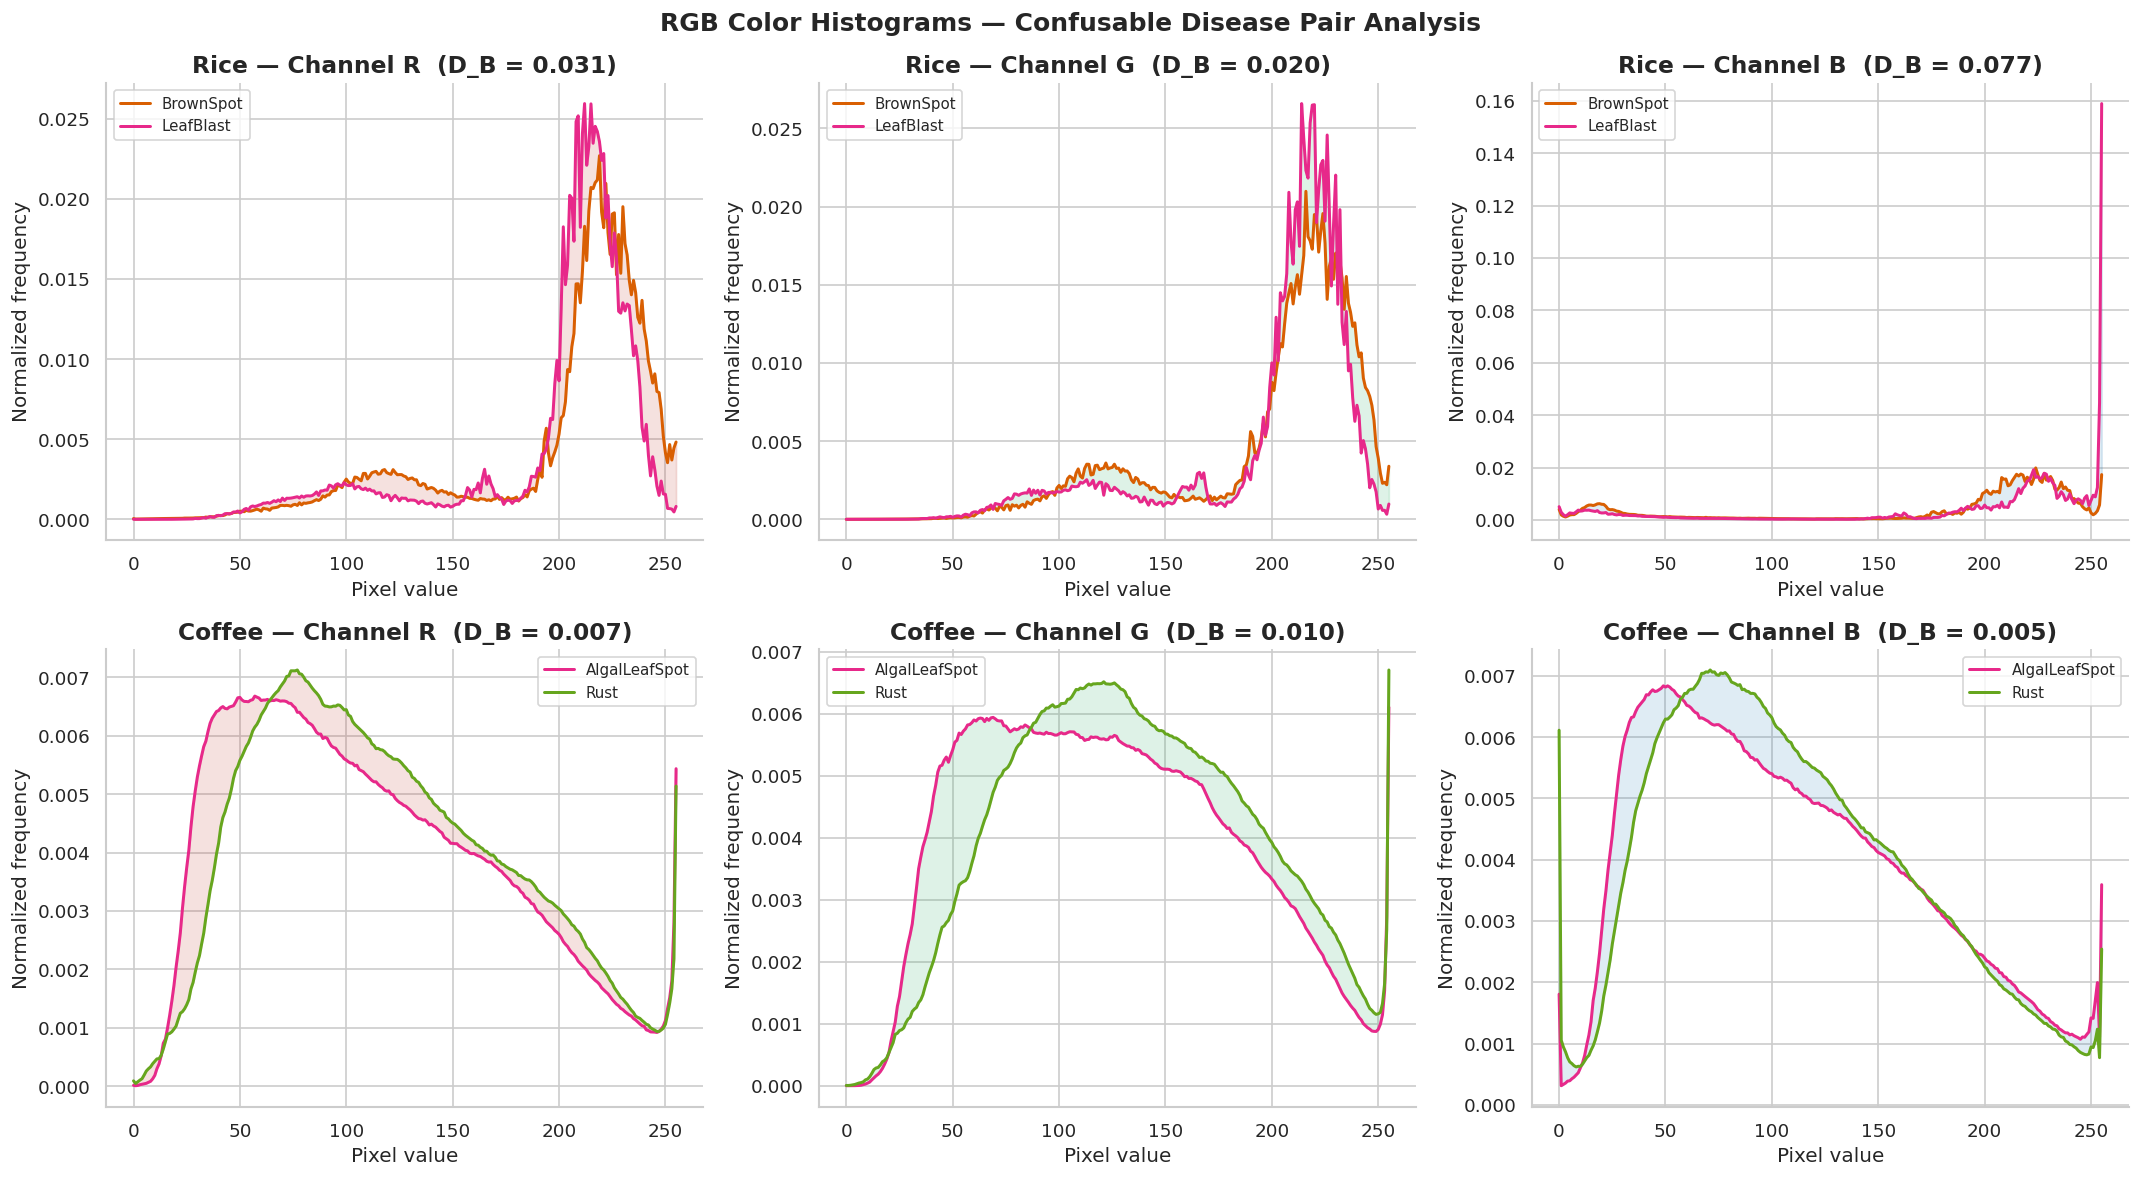

D_B near zero: the two classes have similar color distributions -> the model needs to learn texture features.


In [20]:
# ============================================================
# Color Histogram Comparison — Confusable Disease Pairs
# Uses visualize.compute_mean_histogram()
# ============================================================
rice_hists = {
    cls: compute_mean_histogram(RICE_DIR, cls, RICE_FOLDER)
    for cls in ["BrownSpot", "LeafBlast"]
}
coffee_hists = {
    cls: compute_mean_histogram(COFFEE_DIR, cls, COFFEE_FOLDER)
    for cls in ["AlgalLeafSpot", "Rust"]
}

bins = np.arange(256)
channel_colors = {"R": "#C0392B", "G": "#27AE60", "B": "#2980B9"}
rice_pair_colors   = {"BrownSpot": "#D95F02", "LeafBlast": "#E7298A"}
coffee_pair_colors = {"AlgalLeafSpot": "#E7298A", "Rust": "#66A61E"}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("RGB Color Histograms — Confusable Disease Pair Analysis",
             fontsize=15, fontweight="bold")

for col, ch in enumerate(["R", "G", "B"]):
    ch_color = channel_colors[ch]

    ax_r = axes[0, col]
    h_bs = rice_hists["BrownSpot"][ch]
    h_lb = rice_hists["LeafBlast"][ch]
    ax_r.plot(bins, h_bs, color=rice_pair_colors["BrownSpot"], lw=1.8, label="BrownSpot")
    ax_r.plot(bins, h_lb, color=rice_pair_colors["LeafBlast"],  lw=1.8, label="LeafBlast")
    ax_r.fill_between(bins, h_bs, h_lb, alpha=0.15, color=ch_color)
    bc = np.sum(np.sqrt(np.clip(h_bs * h_lb, 0, None)))
    ax_r.set_title(f"Rice — Channel {ch}  (D_B = {-np.log(bc + 1e-10):.3f})")
    ax_r.set_xlabel("Pixel value")
    ax_r.set_ylabel("Normalized frequency")
    ax_r.legend(fontsize=9)

    ax_c = axes[1, col]
    h_cr = coffee_hists["AlgalLeafSpot"][ch]
    h_ce = coffee_hists["Rust"][ch]
    ax_c.plot(bins, h_cr, color=coffee_pair_colors["AlgalLeafSpot"], lw=1.8, label="AlgalLeafSpot")
    ax_c.plot(bins, h_ce, color=coffee_pair_colors["Rust"],  lw=1.8, label="Rust")
    ax_c.fill_between(bins, h_cr, h_ce, alpha=0.15, color=ch_color)
    bc = np.sum(np.sqrt(np.clip(h_cr * h_ce, 0, None)))
    ax_c.set_title(f"Coffee — Channel {ch}  (D_B = {-np.log(bc + 1e-10):.3f})")
    ax_c.set_xlabel("Pixel value")
    ax_c.set_ylabel("Normalized frequency")
    ax_c.legend(fontsize=9)

plt.tight_layout()
plt.show()

print("D_B near zero: the two classes have similar color distributions -> the model needs to learn texture features.")

---
<a id="sec9"></a>
## 9. Evaluation Metric — Macro F1-score

Based on the class-imbalance analysis in Section 3, **Macro F1-score** is identified as the most appropriate evaluation metric for this task.

### 9.1 Definition

For a set of $C$ classes, Macro F1-score is the unweighted mean of $F1_c$ across all classes:

$$\text{Macro-F1} = \frac{1}{|C|} \sum_{c=1}^{|C|} F1_c$$

where:

$$F1_c = \frac{2 P_c R_c}{P_c + R_c}, \quad P_c = \frac{TP_c}{TP_c + FP_c}, \quad R_c = \frac{TP_c}{TP_c + FN_c}$$

### 9.2 Why Not Accuracy?

With imbalanced data, a model that always predicts the majority class can achieve high accuracy while being useless for minority classes. For example, if Healthy represents 44% of the rice dataset, a model that predicts only "Healthy" reaches approximately 44% accuracy but has Macro F1 = $\frac{1}{4}\left(0 + 1 + 0 + 0\right) = 0.25$.

### 9.3 Implications for Training Strategy

To optimize Macro F1, consider the following techniques:
- **Oversampling** of minority classes (copy augmentation on images).
- **Class-weighted loss:** $\mathcal{L}_{\text{weighted}} = -\sum_{c} w_c \log p_c$, with $w_c \propto 1/N_c$.
- **Threshold tuning** on the validation set to optimize per-class F1.

---
<a id="sec10"></a>
## 10. Summary and Preprocessing Recommendations

### 10.1 Key Findings Summary

| Aspect | Rice | Coffee |
|---|---|---|
| Total images | 3,421 | 3,879 |
| Number of classes | 4 (BrownSpot, Healthy, Hispa, LeafBlast) | 4 (LeafMiner, PowderyMildew, Rust, AlgalLeafSpot) |
| Imbalance Ratio (IR) | ~2.8x (Healthy >> BrownSpot) | ~5.3x (majority class >> minority class) |
| Image dimensions | 132–3120 px, mostly square images | 163–4000 px, many portrait images |
| Brightness | High (mean ~200), highly variable | Lower (mean ~127), structured by class |
| Most confusable pair | BrownSpot ↔ LeafBlast | Rust ↔ AlgalLeafSpot |
| Annotations/image | Mean ~1.09 (max 28) | Nearly 1:1 |

### 10.2 Specific Preprocessing Recommendations

**A. Class imbalance handling (advisory):**
1. Report class counts and consider class-aware sampling or loss weighting per model.
2. Do not change the shared clean dataset solely to balance one experiment.

**B. Image geometry (advisory):**
1. Preserve source-resolution images in the clean dataset.
2. Choose resize, letterbox, and crop settings in each model notebook so polygon coordinates remain valid.

**C. Photometric and geometric augmentation (advisory):**
1. Consider moderate color and orientation augmentation when supported by the model target representation.
2. Record the selected policy in the experiment configuration.

**D. Statistical normalization (advisory):**
1. Compute train-only statistics only when the model requires them.
2. Keep normalization out of the shared clean-dataset contract.

**E. Domain-split handling:**
1. Keep Rice and Coffee partitions independent; do not optimize for a combined Rice:Coffee ratio.
2. Preserve the **domain** field for domain-level error analysis.

---

*EDA complete. Next: Preprocessing Pipeline (notebooks/data/preprocessing.ipynb)*